In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# LOAD DATA
# ============================================================
#df = pd.read_csv("targeted_sdp_synthetic_partial.csv")
#df = pd.read_csv("final_results_synthetics.csv")
df = pd.read_csv("final_results_2273861.csv")

In [3]:
done_nets = df.Network.unique()

In [5]:
for net in done_nets:
    print(net)

bn_n100_w2_concentrated_bias_high.bif
bn_n100_w2_concentrated_bias_low.bif
bn_n100_w2_rigid_extreme.bif
bn_n100_w2_rigid_moderate.bif
bn_n100_w2_spread_bias_high.bif
bn_n100_w2_spread_bias_low.bif
bn_n100_w2_uncertain_moderate.bif
bn_n100_w2_uncertain_strong.bif
bn_n100_w2_uniform.bif
bn_n100_w6_concentrated_bias_high.bif
bn_n100_w6_concentrated_bias_low.bif
bn_n100_w6_rigid_extreme.bif
bn_n100_w6_rigid_moderate.bif
bn_n100_w6_spread_bias_high.bif
bn_n100_w6_spread_bias_low.bif


=== Cell counts (Density × Rigidity) ===
Rigidity     uniform  spread_bias_low  spread_bias_high  \
Density_Cat                                               
Sparse            14               12                14   
Dense              0               10                14   

Rigidity     concentrated_bias_low  concentrated_bias_high  \
Density_Cat                                                  
Sparse                          13                       8   
Dense                            4                      12   

Rigidity     uncertain_moderate  uncertain_strong  rigid_moderate  \
Density_Cat                                                         
Sparse                       14                12              14   
Dense                         0                 0              11   

Rigidity     rigid_extreme  
Density_Cat                 
Sparse                  14  
Dense                   11  



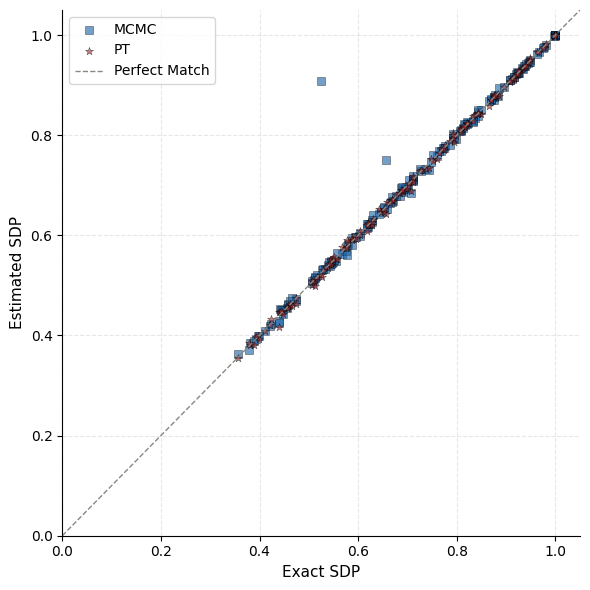

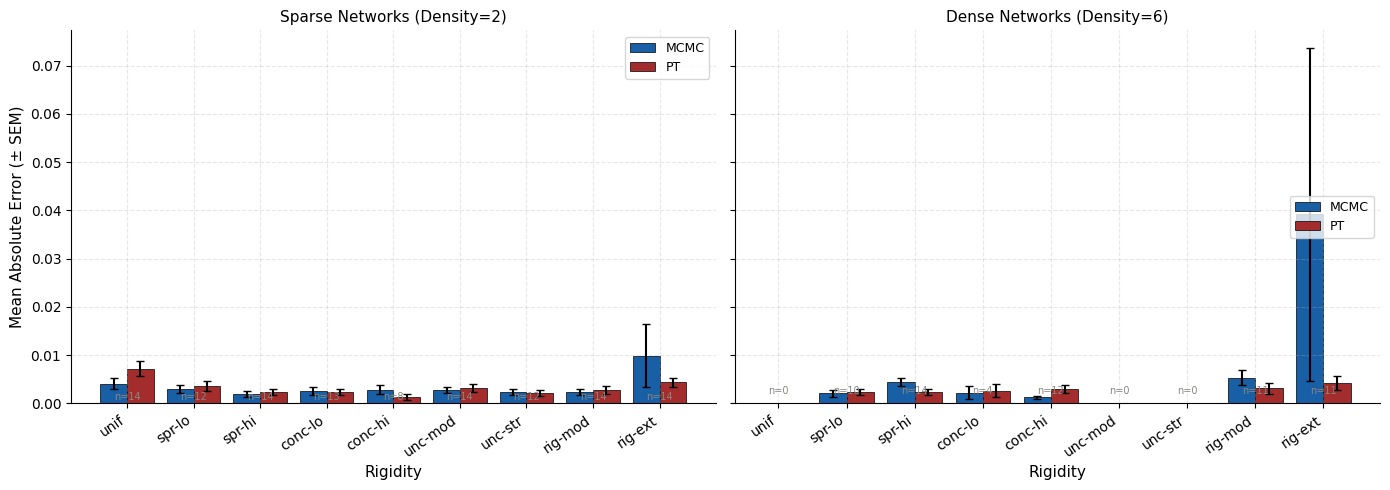

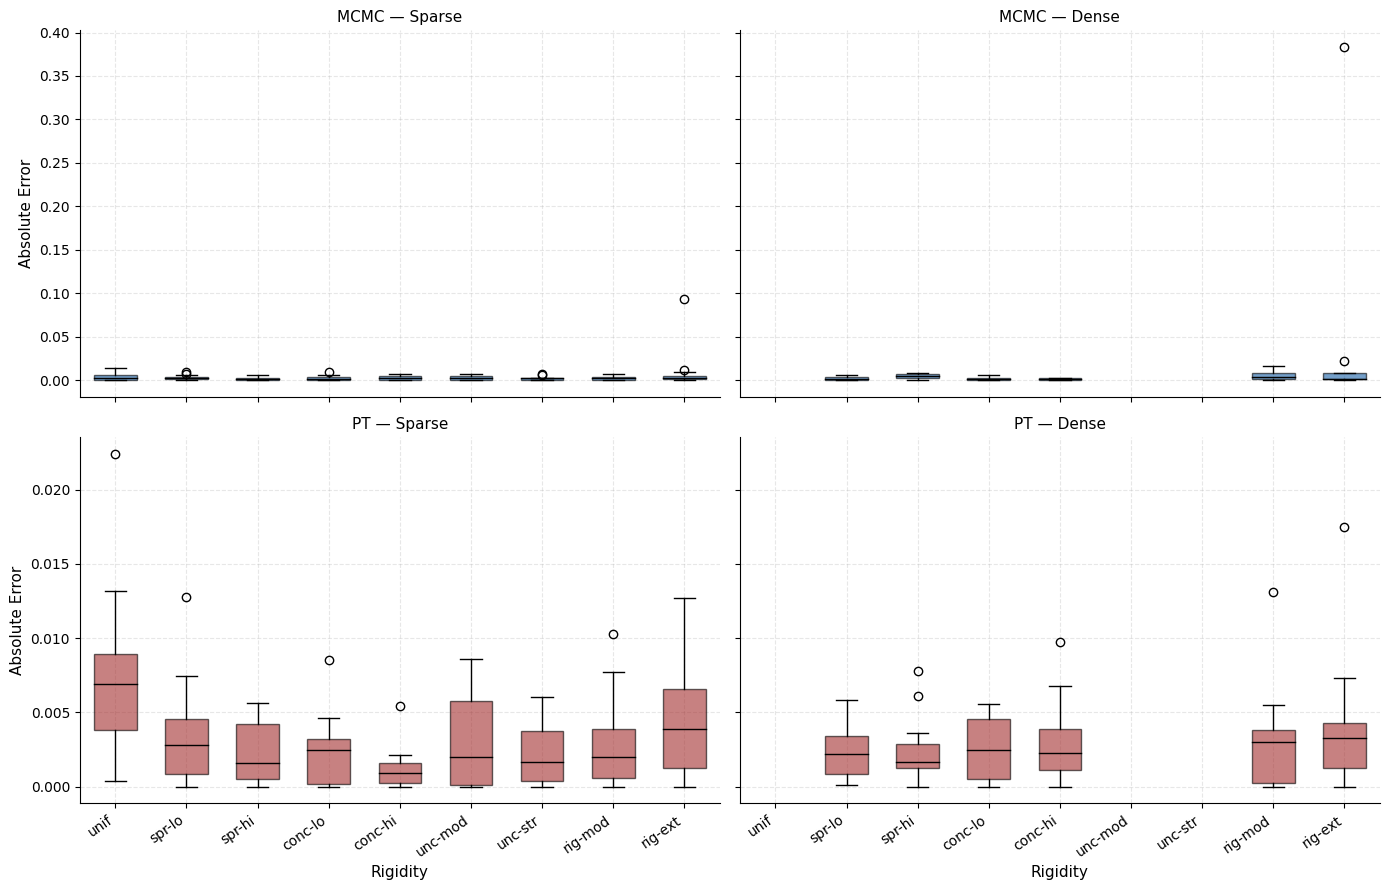

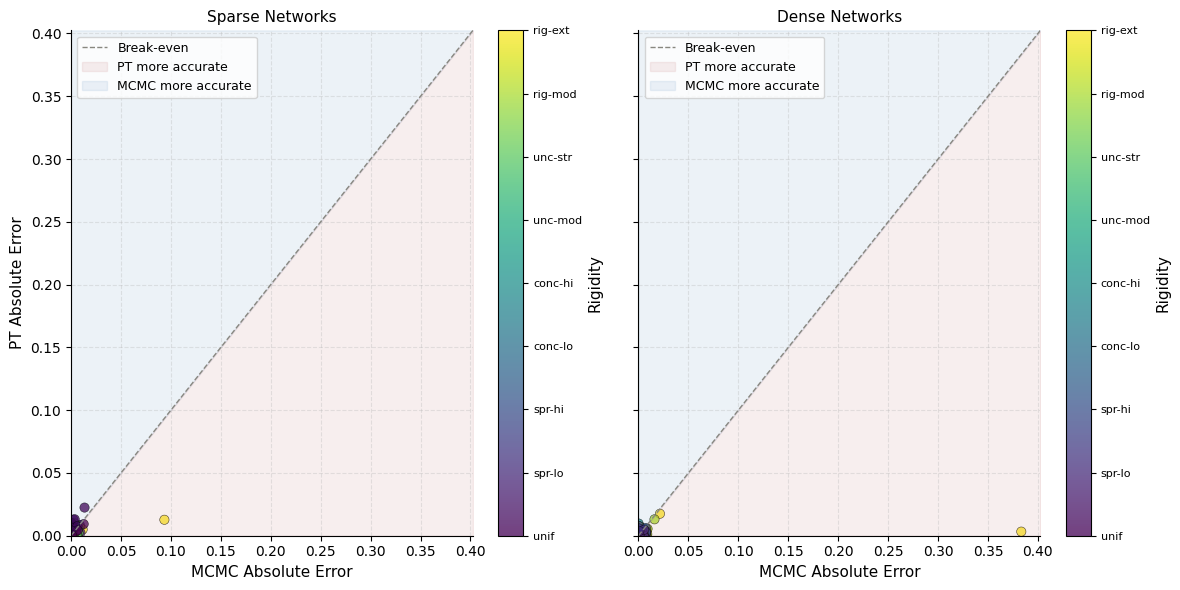

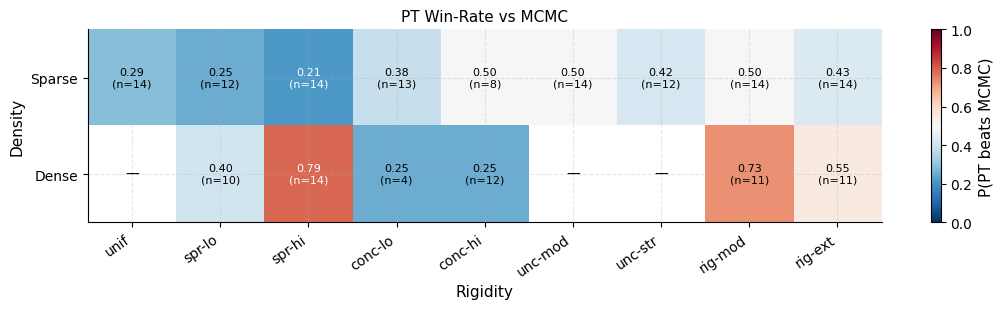

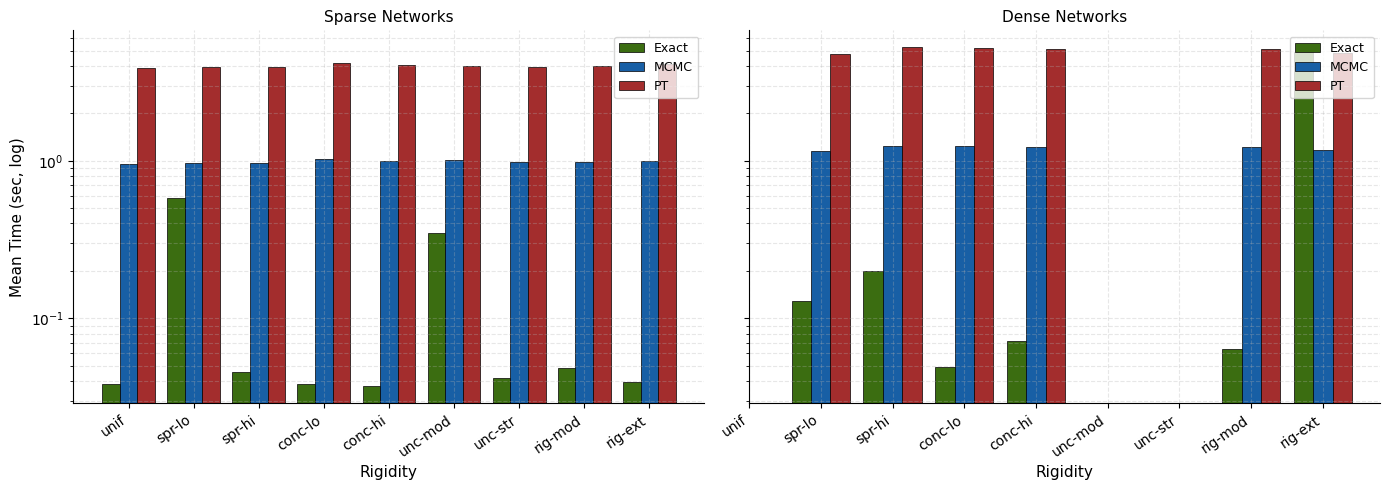


=== Summary by Density × Rigidity ===
                                     n  MCMC_mean_err  MCMC_std_err  \
Density_Cat Rigidity                                                  
Sparse      uniform                 14         0.0041        0.0044   
            spread_bias_low         12         0.0030        0.0029   
            spread_bias_high        14         0.0019        0.0022   
            concentrated_bias_low   13         0.0026        0.0029   
            concentrated_bias_high   8         0.0028        0.0027   
            uncertain_moderate      14         0.0028        0.0025   
            uncertain_strong        12         0.0023        0.0023   
            rigid_moderate          14         0.0024        0.0024   
            rigid_extreme           14         0.0098        0.0243   
Dense       spread_bias_low         10         0.0021        0.0021   
            spread_bias_high        14         0.0044        0.0030   
            concentrated_bias_low    4

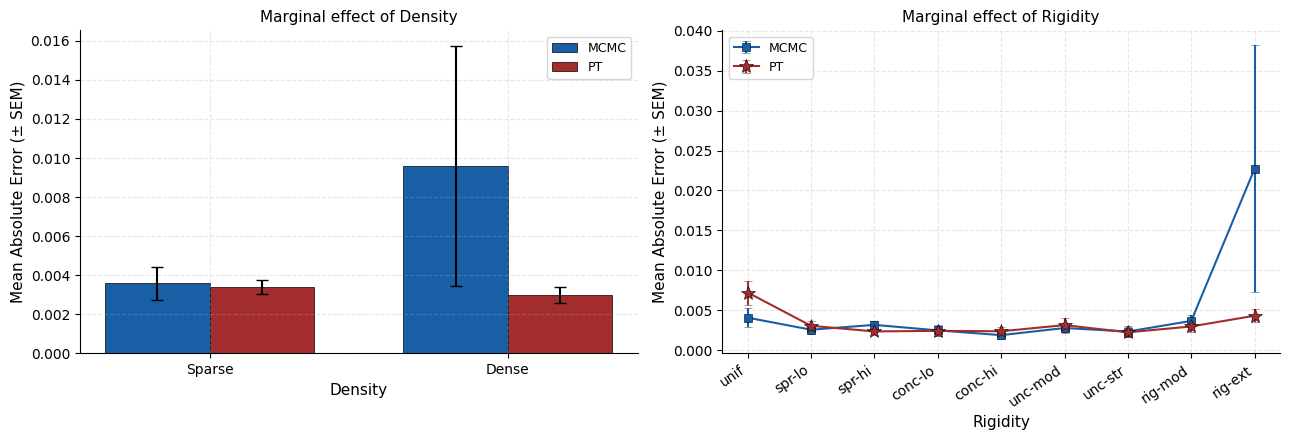

In [ ]:

# ============================================================
# COLORS
# ============================================================
BLUE   = '#185FA5'
RED    = '#A32D2D'
AMBER  = '#B85C00'
GREEN  = '#3B6D11'
GRAY   = '#888780'

METHOD_COLORS  = {'Exact': GREEN, 'MCMC': BLUE, 'PT': RED}
METHOD_MARKERS = {'Exact': 'o',   'MCMC': 's',  'PT': '*'}

# ============================================================
# CATEGORICAL ENCODING
# ============================================================
# Density: 2 = sparse, 6 = dense
df['Density_Cat'] = df['Density'].map({2: 'Sparse', 6: 'Dense'})

# Rigidity: 9 ordered levels, from least to most "opinionated"
RIGIDITY_ORDER = [
    'uniform',
    'spread_bias_low',
    'spread_bias_high',
    'concentrated_bias_low',
    'concentrated_bias_high',
    'uncertain_moderate',
    'uncertain_strong',
    'rigid_moderate',
    'rigid_extreme',
]
# Short labels for axis ticks (the full names are too long for x-ticks)
RIGIDITY_SHORT = {
    'uniform':                'unif',
    'spread_bias_low':        'spr-lo',
    'spread_bias_high':       'spr-hi',
    'concentrated_bias_low':  'conc-lo',
    'concentrated_bias_high': 'conc-hi',
    'uncertain_moderate':     'unc-mod',
    'uncertain_strong':       'unc-str',
    'rigid_moderate':         'rig-mod',
    'rigid_extreme':          'rig-ext',
}
df['Rigidity'] = pd.Categorical(df['Rigidity'],
                                 categories=RIGIDITY_ORDER, ordered=True)
df['Density_Cat'] = pd.Categorical(df['Density_Cat'],
                                    categories=['Sparse', 'Dense'], ordered=True)

print("=== Cell counts (Density × Rigidity) ===")
print(pd.crosstab(df['Density_Cat'], df['Rigidity']))
print()

# Convenience
short_labels = [RIGIDITY_SHORT[r] for r in RIGIDITY_ORDER]
x_pos = np.arange(len(RIGIDITY_ORDER))

# ============================================================
# 1. SANITY CHECK — Exact vs Estimated SDP
# ============================================================
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['Exact_SDP'], df['MCMC_Mean_SDP'],
           color=METHOD_COLORS['MCMC'], alpha=0.6, s=35,
           marker=METHOD_MARKERS['MCMC'], label='MCMC',
           edgecolors='black', linewidths=0.4)
ax.scatter(df['Exact_SDP'], df['PT_MCMC_Mean_SDP'],
           color=METHOD_COLORS['PT'], alpha=0.6, s=35,
           marker=METHOD_MARKERS['PT'], label='PT',
           edgecolors='black', linewidths=0.4)
lims = [0, 1.05]
ax.plot(lims, lims, color=GRAY, ls='--', lw=1, label='Perfect Match')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Exact SDP'); ax.set_ylabel('Estimated SDP')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_1_exact_vs_estimated.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 2. MEAN ABSOLUTE ERROR BY RIGIDITY × DENSITY (grouped bars)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dens in zip(axes, ['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]
    g = sub.groupby('Rigidity', observed=True).agg(
        mcmc_mean=('Absolute_Error',    'mean'),
        mcmc_sem =('Absolute_Error',    'sem'),
        pt_mean  =('PT_Absolute_Error', 'mean'),
        pt_sem   =('PT_Absolute_Error', 'sem'),
    ).reindex(RIGIDITY_ORDER)

    width = 0.4
    ax.bar(x_pos - width/2, g['mcmc_mean'], width, yerr=g['mcmc_sem'],
           capsize=3, color=METHOD_COLORS['MCMC'], label='MCMC',
           edgecolor='black', linewidth=0.5)
    ax.bar(x_pos + width/2, g['pt_mean'], width, yerr=g['pt_sem'],
           capsize=3, color=METHOD_COLORS['PT'], label='PT',
           edgecolor='black', linewidth=0.5)

    n_per_cell = sub.groupby('Rigidity', observed=True).size().reindex(RIGIDITY_ORDER, fill_value=0)
    for i, n in enumerate(n_per_cell):
        ax.text(i, ax.get_ylim()[1] * 0.02, f'n={n}', ha='center',
                va='bottom', fontsize=7, color=GRAY)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_labels, rotation=35, ha='right')
    ax.set_xlabel('Rigidity')
    ax.set_title(f'{dens} Networks (Density={2 if dens=="Sparse" else 6})')
    ax.grid(True, alpha=0.3, axis='y')
    if dens == 'Sparse':
        ax.set_ylabel('Mean Absolute Error (± SEM)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_2_error_by_rigidity_density.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 3. ERROR DISTRIBUTION (boxplots) BY RIGIDITY × DENSITY
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey='row', sharex='col')

for col, dens in enumerate(['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]

    # Build per-cell data, marking empty cells so positions stay aligned
    mcmc_data, pt_data, mcmc_pos, pt_pos = [], [], [], []
    for i, r in enumerate(RIGIDITY_ORDER):
        cell = sub[sub['Rigidity'] == r]
        if len(cell) > 0:
            mcmc_data.append(cell['Absolute_Error'].values)
            pt_data.append(cell['PT_Absolute_Error'].values)
            mcmc_pos.append(i)
            pt_pos.append(i)

    # MCMC
    if mcmc_data:
        bp = axes[0, col].boxplot(mcmc_data, positions=mcmc_pos, widths=0.6,
                                   patch_artist=True,
                                   medianprops=dict(color='black'))
        for p in bp['boxes']:
            p.set_facecolor(METHOD_COLORS['MCMC']); p.set_alpha(0.6)
    axes[0, col].set_title(f'MCMC — {dens}')
    axes[0, col].set_xlim(-0.5, len(RIGIDITY_ORDER) - 0.5)
    axes[0, col].grid(True, alpha=0.3, axis='y')

    # PT
    if pt_data:
        bp = axes[1, col].boxplot(pt_data, positions=pt_pos, widths=0.6,
                                   patch_artist=True,
                                   medianprops=dict(color='black'))
        for p in bp['boxes']:
            p.set_facecolor(METHOD_COLORS['PT']); p.set_alpha(0.6)
    axes[1, col].set_title(f'PT — {dens}')
    axes[1, col].set_xticks(x_pos)
    axes[1, col].set_xticklabels(short_labels, rotation=35, ha='right')
    axes[1, col].set_xlabel('Rigidity')
    axes[1, col].set_xlim(-0.5, len(RIGIDITY_ORDER) - 0.5)
    axes[1, col].grid(True, alpha=0.3, axis='y')

axes[0, 0].set_ylabel('Absolute Error')
axes[1, 0].set_ylabel('Absolute Error')
plt.tight_layout()
plt.savefig('plot_3_error_distribution_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 4. PT vs MCMC HEAD-TO-HEAD — split by density
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

max_err = max(df['Absolute_Error'].max(), df['PT_Absolute_Error'].max())
lims2 = [0, max_err * 1.05]

# Use integer codes for the rigidity colorbar
rig_codes = df['Rigidity'].cat.codes

for ax, dens in zip(axes, ['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]
    sc = ax.scatter(sub['Absolute_Error'], sub['PT_Absolute_Error'],
                    c=sub['Rigidity'].cat.codes, cmap='viridis',
                    vmin=0, vmax=len(RIGIDITY_ORDER) - 1,
                    alpha=0.75, s=45, edgecolors='black', linewidths=0.4)

    ax.plot(lims2, lims2, color=GRAY, ls='--', lw=1, label='Break-even')
    ax.fill_between(lims2, 0, lims2, color=METHOD_COLORS['PT'],   alpha=0.08,
                    label='PT more accurate')
    ax.fill_between(lims2, lims2, [lims2[1]] * 2, color=METHOD_COLORS['MCMC'],
                    alpha=0.08, label='MCMC more accurate')

    ax.set_xlim(lims2); ax.set_ylim(lims2)
    ax.set_xlabel('MCMC Absolute Error')
    ax.set_title(f'{dens} Networks')
    ax.grid(True, alpha=0.3); ax.legend(loc='upper left', fontsize=9)
    cbar = plt.colorbar(sc, ax=ax, ticks=x_pos)
    cbar.ax.set_yticklabels(short_labels, fontsize=8)
    cbar.set_label('Rigidity')

axes[0].set_ylabel('PT Absolute Error')
plt.tight_layout()
plt.savefig('plot_4_head_to_head_by_density.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 5. WIN-RATE HEATMAP — where does PT beat MCMC?
# ============================================================
df['PT_Wins'] = (df['PT_Absolute_Error'] < df['Absolute_Error']).astype(int)

win_table = df.groupby(['Density_Cat', 'Rigidity'], observed=True)['PT_Wins'] \
              .mean().unstack().reindex(columns=RIGIDITY_ORDER) \
              .reindex(['Sparse', 'Dense'])
n_table = df.groupby(['Density_Cat', 'Rigidity'], observed=True).size() \
             .unstack(fill_value=0).reindex(columns=RIGIDITY_ORDER) \
             .reindex(['Sparse', 'Dense'])

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(win_table.values, cmap='RdBu_r', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(x_pos); ax.set_xticklabels(short_labels, rotation=35, ha='right')
ax.set_yticks(range(len(win_table.index)))
ax.set_yticklabels(win_table.index)
ax.set_xlabel('Rigidity'); ax.set_ylabel('Density')

for i in range(win_table.shape[0]):
    for j in range(win_table.shape[1]):
        v = win_table.values[i, j]
        n = n_table.values[i, j]
        if pd.isna(v):
            ax.text(j, i, '—', ha='center', va='center', color='black', fontsize=10)
        else:
            color = 'white' if abs(v - 0.5) > 0.25 else 'black'
            ax.text(j, i, f'{v:.2f}\n(n={n})', ha='center', va='center',
                    color=color, fontsize=8)

cbar = plt.colorbar(im, ax=ax); cbar.set_label('P(PT beats MCMC)')
ax.set_title('PT Win-Rate vs MCMC')
plt.tight_layout()
plt.savefig('plot_5_pt_winrate.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 6. EXECUTION TIME BY RIGIDITY × DENSITY (log scale)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dens in zip(axes, ['Sparse', 'Dense']):
    sub = df[df['Density_Cat'] == dens]
    g = sub.groupby('Rigidity', observed=True).agg(
        exact=('Exact_Time_sec',       'mean'),
        mcmc =('MCMC_Avg_Time_sec',    'mean'),
        pt   =('PT_MCMC_Avg_Time_sec', 'mean'),
    ).reindex(RIGIDITY_ORDER)

    width = 0.27
    ax.bar(x_pos - width, g['exact'], width, color=METHOD_COLORS['Exact'],
           label='Exact', edgecolor='black', linewidth=0.5)
    ax.bar(x_pos,         g['mcmc'],  width, color=METHOD_COLORS['MCMC'],
           label='MCMC',  edgecolor='black', linewidth=0.5)
    ax.bar(x_pos + width, g['pt'],    width, color=METHOD_COLORS['PT'],
           label='PT',    edgecolor='black', linewidth=0.5)

    ax.set_yscale('log')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(short_labels, rotation=35, ha='right')
    ax.set_xlabel('Rigidity')
    ax.set_title(f'{dens} Networks')
    ax.grid(True, alpha=0.3, axis='y', which='both')
    if dens == 'Sparse':
        ax.set_ylabel('Mean Time (sec, log)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_6_time_by_rigidity_density.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 7. SUMMARY TABLE
# ============================================================
summary = df.groupby(['Density_Cat', 'Rigidity'], observed=True).agg(
    n              =('Absolute_Error',       'size'),
    MCMC_mean_err  =('Absolute_Error',       'mean'),
    MCMC_std_err   =('Absolute_Error',       'std'),
    MCMC_max_err   =('Absolute_Error',       'max'),
    PT_mean_err    =('PT_Absolute_Error',    'mean'),
    PT_std_err     =('PT_Absolute_Error',    'std'),
    PT_max_err     =('PT_Absolute_Error',    'max'),
    PT_winrate     =('PT_Wins',              'mean'),
    Exact_mean_time=('Exact_Time_sec',       'mean'),
    MCMC_mean_time =('MCMC_Avg_Time_sec',    'mean'),
    PT_mean_time   =('PT_MCMC_Avg_Time_sec', 'mean'),
).round(4)

print("\n=== Summary by Density × Rigidity ===")
print(summary)
summary.to_csv('summary_density_rigidity.csv')

# ============================================================
# 8. MARGINAL EFFECTS — overall view of the two factors
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Marginal effect of density
dens_summary = df.groupby('Density_Cat', observed=True).agg(
    mcmc_mean=('Absolute_Error',    'mean'),
    mcmc_sem =('Absolute_Error',    'sem'),
    pt_mean  =('PT_Absolute_Error', 'mean'),
    pt_sem   =('PT_Absolute_Error', 'sem'),
)
xd = np.arange(len(dens_summary)); width = 0.35
axes[0].bar(xd - width/2, dens_summary['mcmc_mean'], width,
            yerr=dens_summary['mcmc_sem'], capsize=4,
            color=METHOD_COLORS['MCMC'], label='MCMC',
            edgecolor='black', linewidth=0.5)
axes[0].bar(xd + width/2, dens_summary['pt_mean'], width,
            yerr=dens_summary['pt_sem'], capsize=4,
            color=METHOD_COLORS['PT'], label='PT',
            edgecolor='black', linewidth=0.5)
axes[0].set_xticks(xd); axes[0].set_xticklabels(dens_summary.index)
axes[0].set_xlabel('Density')
axes[0].set_ylabel('Mean Absolute Error (± SEM)')
axes[0].set_title('Marginal effect of Density')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')

# (b) Marginal effect of rigidity
rig_summary = df.groupby('Rigidity', observed=True).agg(
    mcmc_mean=('Absolute_Error',    'mean'),
    mcmc_sem =('Absolute_Error',    'sem'),
    pt_mean  =('PT_Absolute_Error', 'mean'),
    pt_sem   =('PT_Absolute_Error', 'sem'),
).reindex(RIGIDITY_ORDER)

axes[1].errorbar(x_pos, rig_summary['mcmc_mean'], yerr=rig_summary['mcmc_sem'],
                 fmt='-s', color=METHOD_COLORS['MCMC'], label='MCMC',
                 capsize=3, lw=1.5, markeredgecolor='black', markeredgewidth=0.4)
axes[1].errorbar(x_pos, rig_summary['pt_mean'], yerr=rig_summary['pt_sem'],
                 fmt='-*', color=METHOD_COLORS['PT'], label='PT',
                 capsize=3, lw=1.5, markersize=10,
                 markeredgecolor='black', markeredgewidth=0.4)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(short_labels, rotation=35, ha='right')
axes[1].set_xlabel('Rigidity')
axes[1].set_ylabel('Mean Absolute Error (± SEM)')
axes[1].set_title('Marginal effect of Rigidity')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plot_8_marginal_effects.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
df.columns

Index(['Network', 'N_Nodes', 'Density', 'Rigidity', 'Hidden_Ratio',
       'Target_Bucket', 'Target_Node', 'Target_Value', 'Number_Subnetworks',
       'Max_Partition_Size', 'Max_Tensor_Size', 'Threshold_Distance',
       'Exact_SDP', 'Exact_Time_sec', 'Exact_Peak_Memory_MB_Python',
       'Exact_Peak_Memory_MB_RSS', 'Exact_SDP_Original',
       'Exact_Time_sec_Original', 'Exact_Peak_Memory_MB_Python_Original',
       'Exact_Peak_Memory_MB_RSS_Original', 'Exact_SDP_Original_Status',
       'MCMC_Mean_SDP', 'MCMC_Variance', 'MCMC_Avg_Time_sec',
       'MCMC_Peak_Memory_MB_Python', 'MCMC_Peak_Memory_MB_RSS',
       'Absolute_Error', 'PT_MCMC_Mean_SDP', 'PT_MCMC_Variance',
       'PT_MCMC_Avg_Time_sec', 'PT_Peak_Memory_MB_Python',
       'PT_Peak_Memory_MB_RSS', 'PT_Absolute_Error', 'Density_Cat', 'PT_Wins'],
      dtype='object')

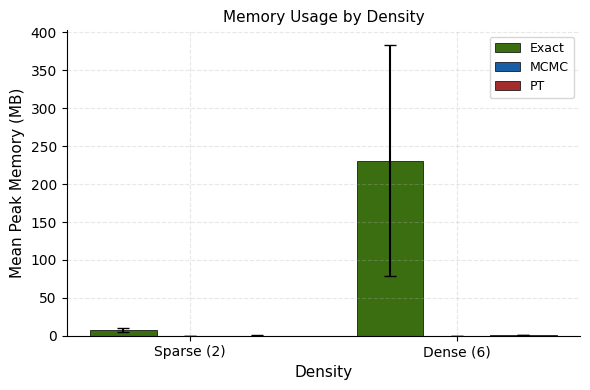

In [23]:
# how density affects memory usage (Exact_Peak_Memory_MB, MCMC_Peak_Memory_MB, PT_Peak_Memory_MB)
memory_summary = df.groupby('Density', observed=True).agg(
    exact_mem_mean=('Exact_Peak_Memory_MB_Python', 'mean'),
    exact_mem_sem =('Exact_Peak_Memory_MB_Python', 'sem'),
    mcmc_mem_mean =('MCMC_Peak_Memory_MB_Python', 'mean'),
    mcmc_mem_sem  =('MCMC_Peak_Memory_MB_Python', 'sem'),
    pt_mem_mean   =('PT_Peak_Memory_MB_Python', 'mean'),
    pt_mem_sem    =('PT_Peak_Memory_MB_Python', 'sem'),
)

# plot
fig, ax = plt.subplots(figsize=(6, 4))
xd = np.arange(len(memory_summary)); width = 0.25
ax.bar(xd - width, memory_summary['exact_mem_mean'], width,
       yerr=memory_summary['exact_mem_sem'], capsize=4,
       color=METHOD_COLORS['Exact'], label='Exact',
       edgecolor='black', linewidth=0.5)
ax.bar(xd, memory_summary['mcmc_mem_mean'], width,
       yerr=memory_summary['mcmc_mem_sem'], capsize=4,
       color=METHOD_COLORS['MCMC'], label='MCMC',
       edgecolor='black', linewidth=0.5)
ax.bar(xd + width, memory_summary['pt_mem_mean'], width,
       yerr=memory_summary['pt_mem_sem'], capsize=4,
       color=METHOD_COLORS['PT'], label='PT',
       edgecolor='black', linewidth=0.5)
ax.set_xticks(xd); ax.set_xticklabels(['Sparse (2)', 'Dense (6)'])
ax.set_xlabel('Density')
ax.set_ylabel('Mean Peak Memory (MB)')
ax.set_title('Memory Usage by Density')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
#plt.savefig('memory_usage_by_density.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
df.N_Nodes.value_counts()

100    177
Name: N_Nodes, dtype: int64

In [25]:
from bn_entropy import *
import glob
import os
from pgmpy.readwrite import BIFWriter, BIFReader

In [26]:
bif_files = sorted(glob.glob(os.path.join("/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/generated_bif_files", "*.bif")))

In [27]:
def parse_bn_filename(filename):
    base = os.path.basename(filename).replace('.bif', '').replace('bn_', '')
    parts = base.split('_')
    n_nodes = int(parts[0].replace('n', ''))
    density = int(parts[1].replace('w', ''))
    # Take every remaining part as type_CPT, joined by underscores
    type_CPT = '_'.join(parts[2:])
    return n_nodes, density, type_CPT

In [28]:
entropies = {}
for file in bif_files:
    base = os.path.basename(file)
    n, d, cpt = parse_bn_filename(file)
    if d != 12:
        print(base)
        bn = BIFReader(file).get_model()
        entropy = mean_conditional_entropy(bn)
        entropies[base] = entropy


bn_n100_w2_concentrated_bias_high.bif
bn_n100_w2_concentrated_bias_low.bif
bn_n100_w2_rigid_extreme.bif
bn_n100_w2_rigid_moderate.bif
bn_n100_w2_spread_bias_high.bif
bn_n100_w2_spread_bias_low.bif
bn_n100_w2_uncertain_moderate.bif
bn_n100_w2_uncertain_strong.bif
bn_n100_w2_uniform.bif
bn_n100_w6_concentrated_bias_high.bif
bn_n100_w6_concentrated_bias_low.bif
bn_n100_w6_rigid_extreme.bif
bn_n100_w6_rigid_moderate.bif
bn_n100_w6_spread_bias_high.bif
bn_n100_w6_spread_bias_low.bif
bn_n100_w6_uncertain_moderate.bif
bn_n100_w6_uncertain_strong.bif
bn_n100_w6_uniform.bif
bn_n200_w2_concentrated_bias_high.bif
bn_n200_w2_concentrated_bias_low.bif
bn_n200_w2_rigid_extreme.bif
bn_n200_w2_rigid_moderate.bif
bn_n200_w2_spread_bias_high.bif
bn_n200_w2_spread_bias_low.bif
bn_n200_w2_uncertain_moderate.bif
bn_n200_w2_uncertain_strong.bif
bn_n200_w2_uniform.bif
bn_n200_w6_concentrated_bias_high.bif
bn_n200_w6_concentrated_bias_low.bif
bn_n200_w6_rigid_extreme.bif
bn_n200_w6_rigid_moderate.bif
bn_n200_

In [29]:
df["Normalized_Entropy"] = df["Network"].map(entropies)

In [30]:
# save entropies to csv
entropy_df = pd.DataFrame.from_dict(entropies, orient='index', columns=['Mean_Conditional_Entropy'])
entropy_df.to_csv('synthetic_network_entropies.csv')

In [31]:
df.head()

,Network,N_Nodes,Density,Rigidity,Hidden_Ratio,Target_Bucket,Target_Node,Target_Value,Number_Subnetworks,Max_Partition_Size,...,Absolute_Error,PT_MCMC_Mean_SDP,PT_MCMC_Variance,PT_MCMC_Avg_Time_sec,PT_Peak_Memory_MB_Python,PT_Peak_Memory_MB_RSS,PT_Absolute_Error,Density_Cat,PT_Wins,Normalized_Entropy
0,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.25,0.5,X4,1,15,4,...,0.003970,0.4738,0.000297,4.359977,0.301787,0.0,0.000330,Sparse,1,0.537673
1,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.25,0.8,X4,1,17,3,...,0.004066,0.8170,0.000050,3.855537,0.274520,0.0,0.000766,Sparse,1,0.537673
2,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.25,0.9,X4,1,15,4,...,0.001552,0.9550,0.000056,4.173990,0.284065,0.0,0.005452,Sparse,0,0.537673
3,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.25,1.0,X4,1,18,5,...,0.000000,1.0000,0.000000,3.976135,0.280487,0.0,0.000000,Sparse,0,0.537673
4,bn_n100_w2_concentrated_bias_high.bif,100,2,concentrated_bias_high,0.50,0.5,X4,1,15,12,...,0.006745,0.4584,0.000132,4.079318,0.295380,0.0,0.001445,Sparse,1,0.537673


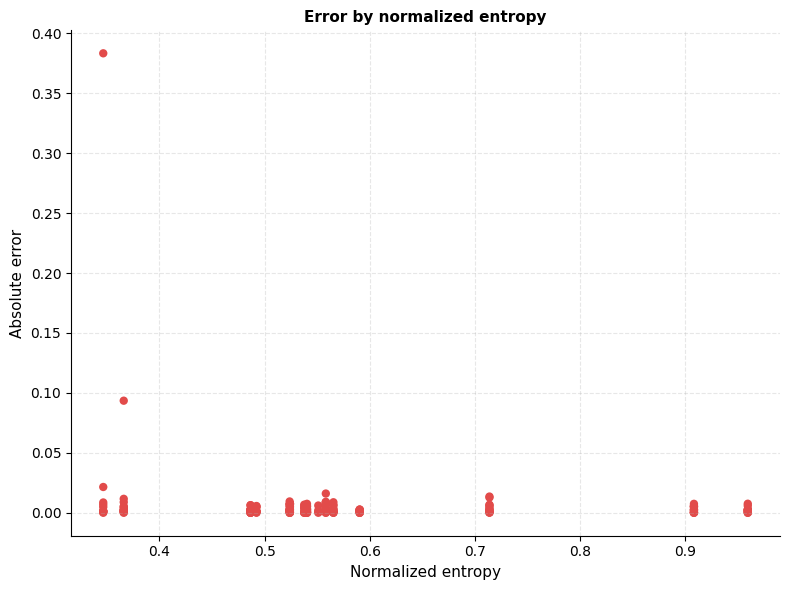

In [32]:
# Error by normalized entropy
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["Normalized_Entropy"], df["Absolute_Error"], color="#E24B4A", edgecolor="none")
ax.set_title("Error by normalized entropy", fontsize=11, fontweight="bold")
ax.set_xlabel("Normalized entropy")
ax.set_ylabel("Absolute error")
plt.tight_layout()
#plt.savefig("benchmark_error_by_normalized_entropy.png", dpi=150, bbox_inches="tight")
plt.show()

Rows with entropy: 177 / 177
Entropy range: [0.347, 0.959]


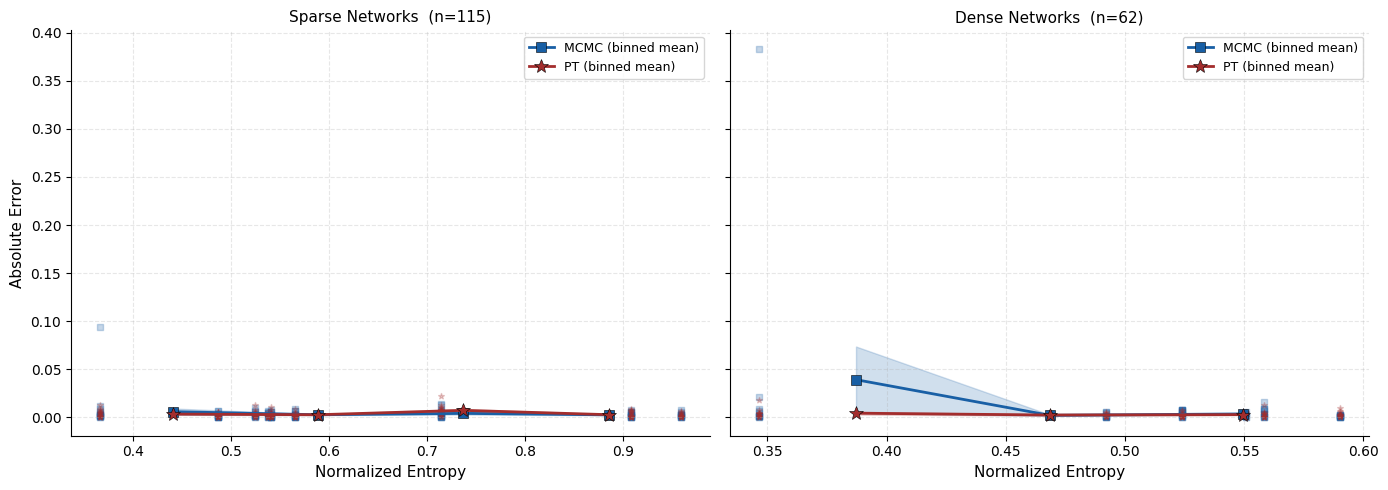


=== Correlation: Entropy vs Absolute Error ===
Subset               Method  Pearson r          p   Spearman ρ          p
---------------------------------------------------------------------------
All                  MCMC       -0.131     0.0812       -0.063     0.4036
All                  PT         -0.001     0.9882       -0.003     0.9686
Sparse               MCMC       -0.122     0.1949       -0.016     0.8614
Sparse               PT          0.003     0.9739        0.000     0.9980
Dense                MCMC       -0.266     0.0367       -0.132     0.3081
Dense                PT         -0.144     0.2627       -0.078     0.5483

=== OLS: Error ~ Entropy + Density + Entropy:Density ===

MCMC: R² = 0.076
  intercept       = +0.00716
  entropy         = -0.00573
  dense           = +0.08229
  entropy × dense = -0.15143

PT: R² = 0.009
  intercept       = +0.00336
  entropy         = +0.00006
  dense           = +0.00248
  entropy × dense = -0.00569


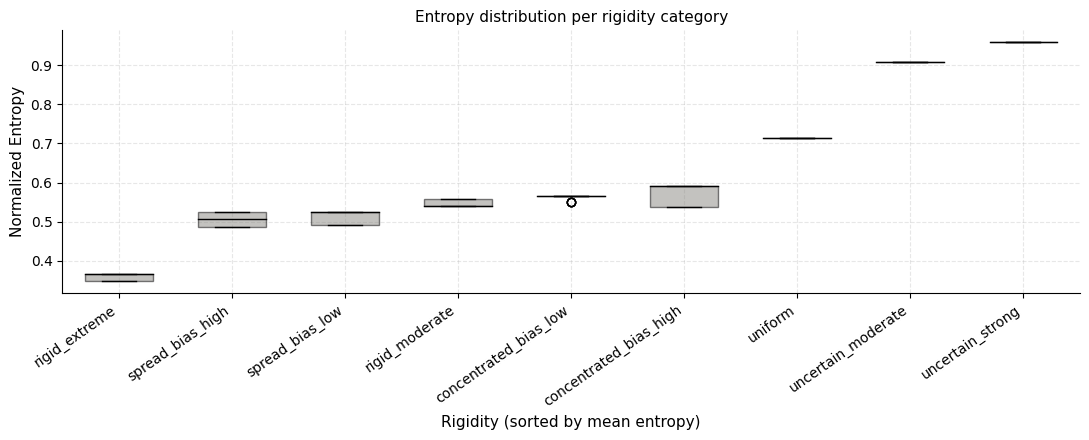

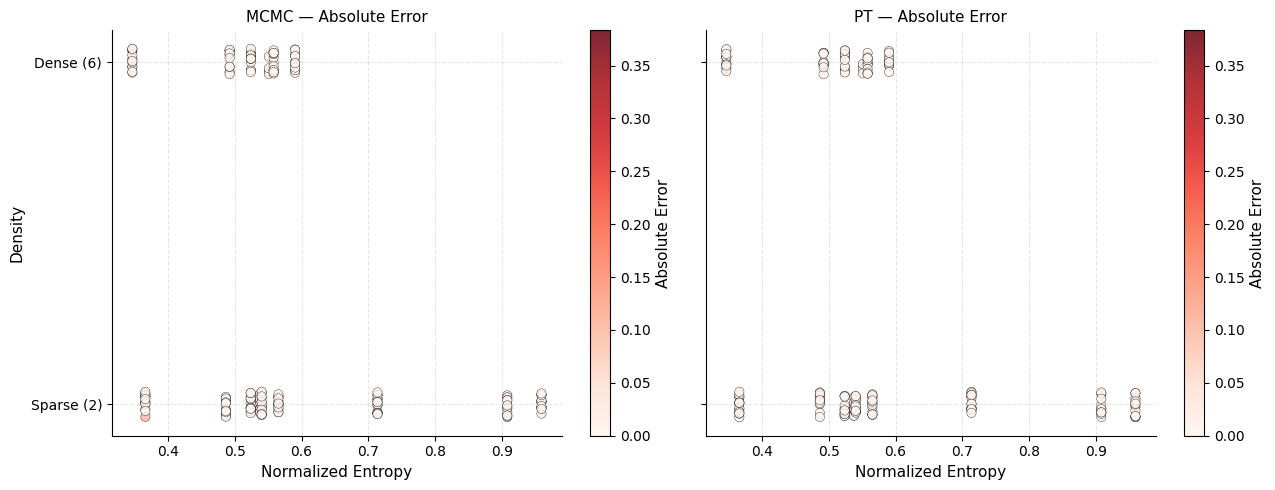

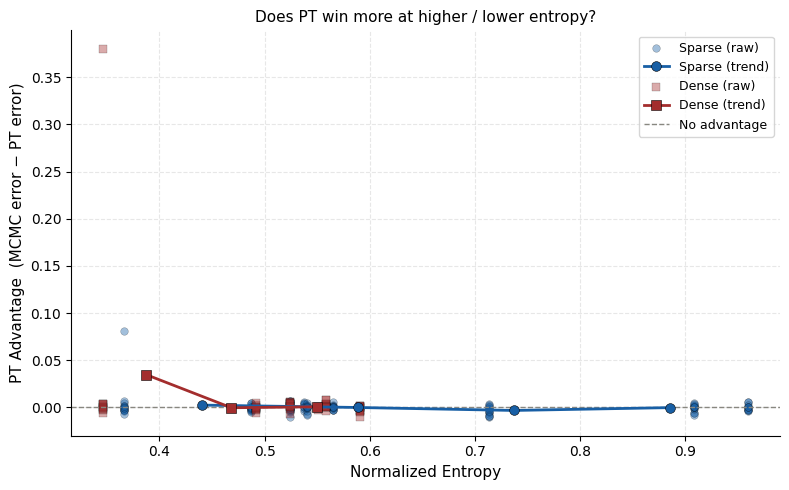


=== Per-network summary (sorted by entropy) ===
                              Network Density_Cat               Rigidity  entropy  mcmc_mean_err  pt_mean_err  n_queries
         bn_n100_w6_rigid_extreme.bif       Dense          rigid_extreme 0.346559       0.039139     0.004272         11
         bn_n100_w2_rigid_extreme.bif      Sparse          rigid_extreme 0.366032       0.009850     0.004339         14
      bn_n100_w2_spread_bias_high.bif      Sparse       spread_bias_high 0.486589       0.001903     0.002345         14
       bn_n100_w6_spread_bias_low.bif       Dense        spread_bias_low 0.492219       0.002073     0.002369         10
       bn_n100_w2_spread_bias_low.bif      Sparse        spread_bias_low 0.523781       0.002958     0.003607         12
      bn_n100_w6_spread_bias_high.bif       Dense       spread_bias_high 0.524029       0.004426     0.002340         14
bn_n100_w2_concentrated_bias_high.bif      Sparse concentrated_bias_high 0.537673       0.002808     0.0

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# ============================================================
# ASSUMES: df already has 'Normalized_Entropy' merged in,
# 'Density_Cat' (Sparse/Dense), and 'Rigidity' as ordered categorical
# ============================================================

# Drop rows where entropy is missing (e.g. networks not in your dict)
ent_df = df.dropna(subset=['Normalized_Entropy']).copy()
print(f"Rows with entropy: {len(ent_df)} / {len(df)}")
print(f"Entropy range: [{ent_df['Normalized_Entropy'].min():.3f}, "
      f"{ent_df['Normalized_Entropy'].max():.3f}]")

# Reuse the same color scheme
BLUE='#185FA5'; RED='#A32D2D'; AMBER='#B85C00'; GREEN='#3B6D11'; GRAY='#888780'
METHOD_COLORS  = {'Exact': GREEN, 'MCMC': BLUE, 'PT': RED}
METHOD_MARKERS = {'Exact': 'o',   'MCMC': 's',  'PT': '*'}

# ============================================================
# 1. ERROR vs ENTROPY — scatter + binned trend, split by density
# ============================================================
def binned_trend(x, y, bins=8):
    """Mean ± SEM of y within bins of x. Returns (centers, means, sems)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    edges = np.linspace(x.min(), x.max(), bins + 1)
    centers = 0.5 * (edges[1:] + edges[:-1])
    means, sems = [], []
    for i in range(bins):
        mask = (x >= edges[i]) & (x <= edges[i + 1])
        if mask.sum() >= 2:
            means.append(y[mask].mean())
            sems.append(y[mask].std(ddof=1) / np.sqrt(mask.sum()))
        else:
            means.append(np.nan); sems.append(np.nan)
    return np.array(centers), np.array(means), np.array(sems)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dens in zip(axes, ['Sparse', 'Dense']):
    sub = ent_df[ent_df['Density_Cat'] == dens]
    if len(sub) == 0:
        continue

    # Scatter raw points (small, transparent)
    ax.scatter(sub['Normalized_Entropy'], sub['Absolute_Error'],
               color=METHOD_COLORS['MCMC'], alpha=0.25, s=18,
               marker=METHOD_MARKERS['MCMC'], label='_nolegend_')
    ax.scatter(sub['Normalized_Entropy'], sub['PT_Absolute_Error'],
               color=METHOD_COLORS['PT'], alpha=0.25, s=18,
               marker=METHOD_MARKERS['PT'], label='_nolegend_')

    # Binned trend with SEM band
    n_bins = min(8, max(3, sub['Normalized_Entropy'].nunique() // 2))
    cx, cm_m, cm_s = binned_trend(sub['Normalized_Entropy'],
                                    sub['Absolute_Error'], bins=n_bins)
    cx2, cp_m, cp_s = binned_trend(sub['Normalized_Entropy'],
                                     sub['PT_Absolute_Error'], bins=n_bins)
    valid_m = ~np.isnan(cm_m); valid_p = ~np.isnan(cp_m)

    ax.plot(cx[valid_m], cm_m[valid_m], color=METHOD_COLORS['MCMC'],
            lw=2, marker='s', markersize=7, label='MCMC (binned mean)',
            markeredgecolor='black', markeredgewidth=0.4, zorder=4)
    ax.fill_between(cx[valid_m],
                    cm_m[valid_m] - cm_s[valid_m],
                    cm_m[valid_m] + cm_s[valid_m],
                    color=METHOD_COLORS['MCMC'], alpha=0.2)

    ax.plot(cx2[valid_p], cp_m[valid_p], color=METHOD_COLORS['PT'],
            lw=2, marker='*', markersize=10, label='PT (binned mean)',
            markeredgecolor='black', markeredgewidth=0.4, zorder=4)
    ax.fill_between(cx2[valid_p],
                    cp_m[valid_p] - cp_s[valid_p],
                    cp_m[valid_p] + cp_s[valid_p],
                    color=METHOD_COLORS['PT'], alpha=0.2)

    ax.set_xlabel('Normalized Entropy')
    ax.set_title(f'{dens} Networks  (n={len(sub)})')
    ax.grid(True, alpha=0.3)
    if dens == 'Sparse':
        ax.set_ylabel('Absolute Error')
    ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('plot_entropy_1_error_vs_entropy.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 2. CORRELATION TESTS — Pearson & Spearman, by density
# ============================================================
print("\n=== Correlation: Entropy vs Absolute Error ===")
print(f"{'Subset':<20} {'Method':<6} {'Pearson r':>10} {'p':>10} "
      f"{'Spearman ρ':>12} {'p':>10}")
print("-" * 75)

for dens in ['All', 'Sparse', 'Dense']:
    sub = ent_df if dens == 'All' else ent_df[ent_df['Density_Cat'] == dens]
    if len(sub) < 3:
        continue
    for method, col in [('MCMC', 'Absolute_Error'), ('PT', 'PT_Absolute_Error')]:
        pr, pp = stats.pearsonr(sub['Normalized_Entropy'], sub[col])
        sr, sp = stats.spearmanr(sub['Normalized_Entropy'], sub[col])
        print(f"{dens:<20} {method:<6} {pr:>10.3f} {pp:>10.4f} "
              f"{sr:>12.3f} {sp:>10.4f}")

# ============================================================
# 3. REGRESSION — Error ~ Entropy * Density (for each method)
# ============================================================
# Encode density as 0/1 and fit error = a + b*entropy + c*density + d*entropy*density
print("\n=== OLS: Error ~ Entropy + Density + Entropy:Density ===")
ent_df['Dense_bin'] = (ent_df['Density_Cat'] == 'Dense').astype(int)

for method, col in [('MCMC', 'Absolute_Error'), ('PT', 'PT_Absolute_Error')]:
    X = np.column_stack([
        np.ones(len(ent_df)),
        ent_df['Normalized_Entropy'].values,
        ent_df['Dense_bin'].values,
        ent_df['Normalized_Entropy'].values * ent_df['Dense_bin'].values,
    ])
    y = ent_df[col].values
    coef, resid, rank, sv = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ coef
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
    print(f"\n{method}: R² = {r2:.3f}")
    print(f"  intercept       = {coef[0]:+.5f}")
    print(f"  entropy         = {coef[1]:+.5f}")
    print(f"  dense           = {coef[2]:+.5f}")
    print(f"  entropy × dense = {coef[3]:+.5f}")

# ============================================================
# 4. WHERE DO RIGIDITY CATEGORIES LAND ON THE ENTROPY AXIS?
# ============================================================
# Sanity check: the rigidity ordering should roughly track entropy
fig, ax = plt.subplots(figsize=(11, 4.5))

# One box per rigidity level, ordered by mean entropy
ent_by_rig = ent_df.groupby('Rigidity', observed=True)['Normalized_Entropy'] \
                    .mean().sort_values()
ordered_levels = ent_by_rig.index.tolist()

box_data = [ent_df.loc[ent_df['Rigidity'] == r, 'Normalized_Entropy'].values
            for r in ordered_levels]
bp = ax.boxplot(box_data, positions=range(len(ordered_levels)),
                widths=0.6, patch_artist=True,
                medianprops=dict(color='black'))
for patch in bp['boxes']:
    patch.set_facecolor(GRAY); patch.set_alpha(0.5)

ax.set_xticks(range(len(ordered_levels)))
ax.set_xticklabels(ordered_levels, rotation=35, ha='right')
ax.set_ylabel('Normalized Entropy')
ax.set_xlabel('Rigidity (sorted by mean entropy)')
ax.set_title('Entropy distribution per rigidity category')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plot_entropy_2_rigidity_mapping.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 5. 2D MAP — error magnitude across the (entropy, density) space
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

vmax = max(ent_df['Absolute_Error'].max(), ent_df['PT_Absolute_Error'].max())

for ax, (method, col) in zip(axes, [('MCMC', 'Absolute_Error'),
                                      ('PT', 'PT_Absolute_Error')]):
    # Jitter density slightly for visibility (it's binary 2 or 6)
    jitter = np.random.uniform(-0.15, 0.15, size=len(ent_df))
    sc = ax.scatter(ent_df['Normalized_Entropy'],
                    ent_df['Density'] + jitter,
                    c=ent_df[col], cmap='Reds', vmin=0, vmax=vmax,
                    s=45, alpha=0.85, edgecolors='black', linewidths=0.3)
    ax.set_yticks([2, 6])
    ax.set_yticklabels(['Sparse (2)', 'Dense (6)'])
    ax.set_xlabel('Normalized Entropy')
    ax.set_title(f'{method} — Absolute Error')
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Absolute Error')

axes[0].set_ylabel('Density')
plt.tight_layout()
plt.savefig('plot_entropy_3_2d_map.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 6. PT ADVANTAGE vs ENTROPY
# ============================================================
# Does PT's improvement over MCMC scale with entropy?
ent_df['PT_Advantage'] = ent_df['Absolute_Error'] - ent_df['PT_Absolute_Error']

fig, ax = plt.subplots(figsize=(8, 5))
for dens, marker, color in [('Sparse', 'o', BLUE), ('Dense', 's', RED)]:
    sub = ent_df[ent_df['Density_Cat'] == dens]
    ax.scatter(sub['Normalized_Entropy'], sub['PT_Advantage'],
               alpha=0.4, s=30, marker=marker, color=color,
               edgecolors='black', linewidths=0.3, label=f'{dens} (raw)')
    n_bins = min(8, max(3, sub['Normalized_Entropy'].nunique() // 2))
    cx, cm, cs = binned_trend(sub['Normalized_Entropy'],
                                sub['PT_Advantage'], bins=n_bins)
    valid = ~np.isnan(cm)
    ax.plot(cx[valid], cm[valid], color=color, lw=2,
            marker=marker, markersize=7,
            markeredgecolor='black', markeredgewidth=0.4,
            label=f'{dens} (trend)', zorder=4)

ax.axhline(0, color=GRAY, ls='--', lw=1, label='No advantage')
ax.set_xlabel('Normalized Entropy')
ax.set_ylabel('PT Advantage  (MCMC error − PT error)')
ax.set_title('Does PT win more at higher / lower entropy?')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_entropy_4_pt_advantage.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 7. PER-NETWORK SUMMARY — collapse query reps, get one row per network
# ============================================================
# Useful because each network is sampled at multiple targets; this shows
# the "intrinsic" error rate per network alongside its entropy.
net_summary = ent_df.groupby(['Network', 'Density_Cat', 'Rigidity'],
                              observed=True).agg(
    entropy        =('Normalized_Entropy', 'first'),
    mcmc_mean_err  =('Absolute_Error',     'mean'),
    pt_mean_err    =('PT_Absolute_Error',  'mean'),
    n_queries      =('Absolute_Error',     'size'),
).reset_index().sort_values('entropy')

print("\n=== Per-network summary (sorted by entropy) ===")
print(net_summary.to_string(index=False))
net_summary.to_csv('summary_per_network_entropy.csv', index=False)

Total rows          : 177
Chen timeouts       : 4
Chen > 30s (non-TO): 12
MH  median error    : 0.0020
PT  median error    : 0.0025
Max exact memory    : 9216 MB
Max MCMC memory     : 0.21 MB


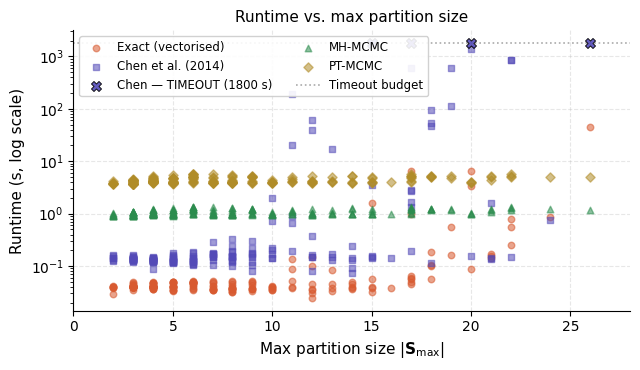

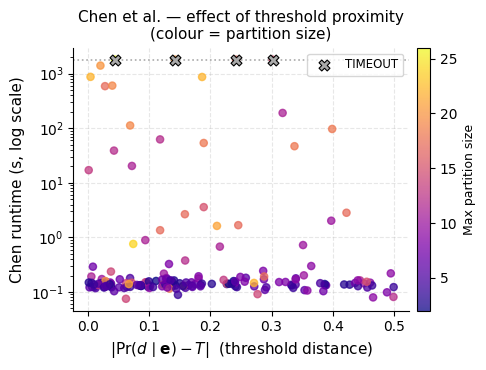

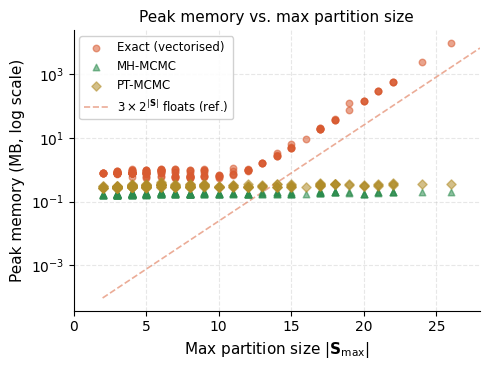

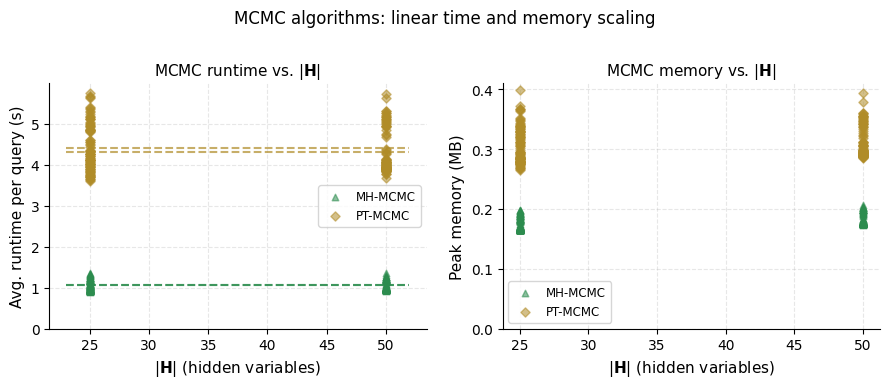

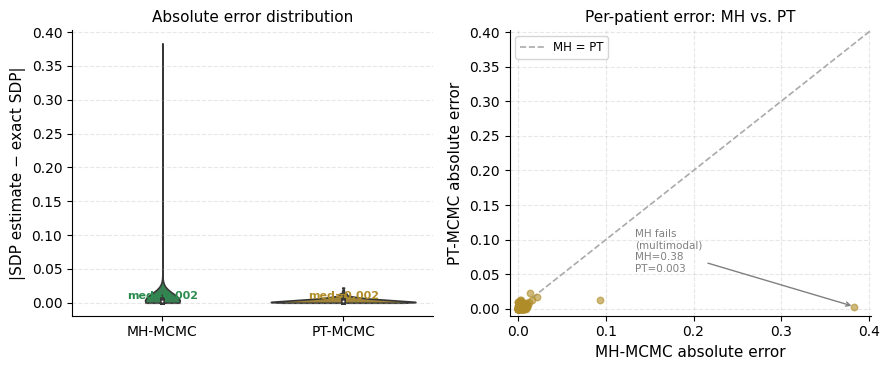

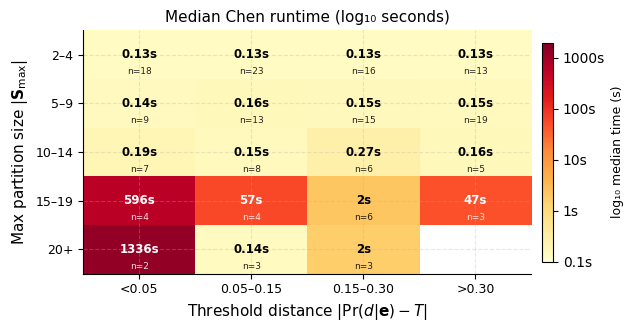

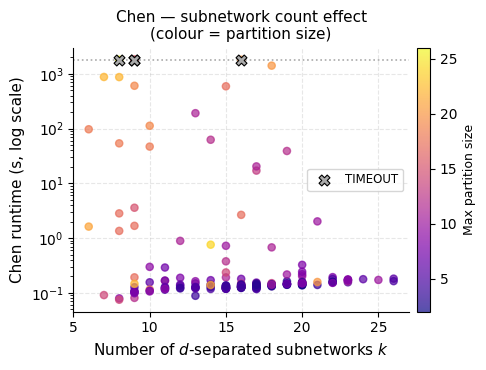

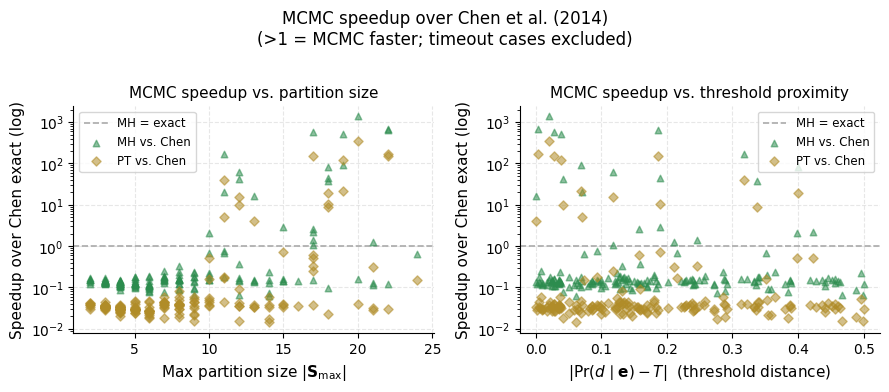


=== Summary Table ===
            Method  Median time (s)  Max time (s)  Median memory (MB)  Max memory (MB)  Failures / 177  Median abs. error  Max abs. error
Exact (vectorised)           0.0411       45.5479              0.8249        9216.4894               0                NaN             NaN
Chen et al. (2014)           0.1435     1800.0000                 NaN              NaN               4                NaN             NaN
           MH-MCMC           1.0156        1.3543              0.1776           0.2075               0             0.0020          0.3833
           PT-MCMC           4.1202        5.7452              0.2994           0.3985               0             0.0025          0.0224

All figures saved to ./figures/


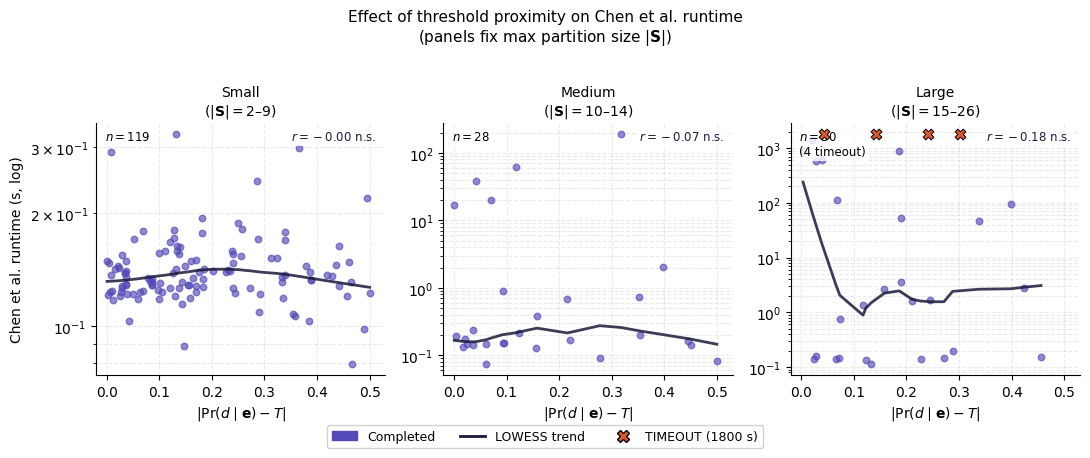

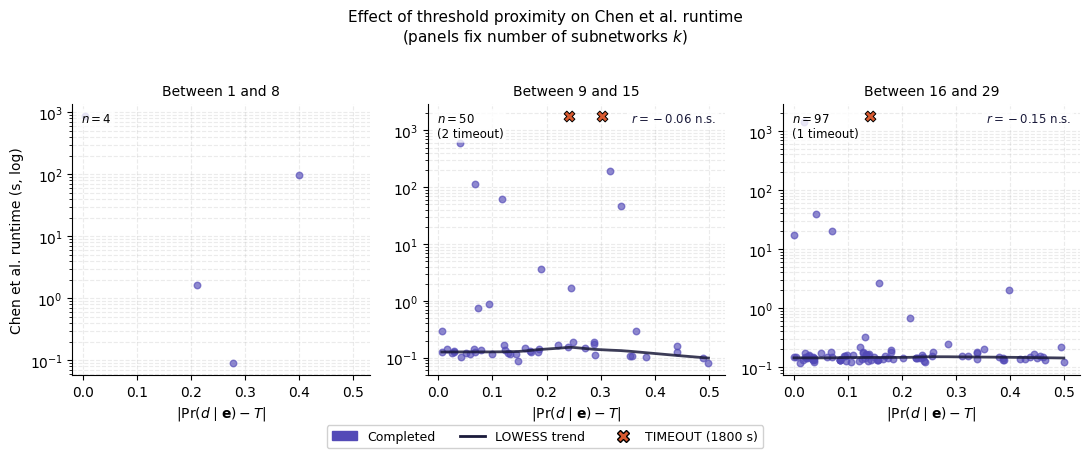

In [34]:
"""
SDP Experiment Analysis — Jupyter Notebook Script
===================================================
Run each cell block in order.  All figures are publication-ready
and saved to ./figures/  (created automatically).

Requires: pandas, numpy, matplotlib, seaborn, scipy
"""

# ── Cell 1 ──────────────────────────────────────────────────────────────────
# Imports & global style
# ────────────────────────────────────────────────────────────────────────────

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.ticker import LogLocator, NullFormatter
from scipy import stats

warnings.filterwarnings("ignore")

os.makedirs("figures", exist_ok=True)

# ── Global palette (colour-blind friendly) ──────────────────────────────────
C_VEC   = "#D85A30"   # Vectorised exact  (orange-red)
C_CHEN  = "#534AB7"   # Chen exact        (violet)
C_MH    = "#2C8C4E"   # MH-MCMC           (green)
C_PT    = "#B08C28"   # PT-MCMC           (gold)
C_LIGHT = "#AAAAAA"   # Timeout markers / annotations

METHOD_LABELS = {
    "Exact (vectorised)": C_VEC,
    "Chen et al. (2014)": C_CHEN,
    "MH-MCMC":            C_MH,
    "PT-MCMC":            C_PT,
}

FIGW = 5.0      # single-column figure width (inches)
FIGH = 3.8      # default figure height

mpl.rcParams.update({
    "font.family":     "sans-serif",
    "font.size":       10,
    "axes.labelsize":  11,
    "axes.titlesize":  11,
    "legend.fontsize": 9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "grid.linestyle":  "--",
})


# ── Cell 2 ──────────────────────────────────────────────────────────────────
# Load & clean data
# ────────────────────────────────────────────────────────────────────────────

CSV_PATH = "final_results_2273861.csv"   # ← update path if needed

df = pd.read_csv(CSV_PATH)
df["N_Hidden"]      = (df["N_Nodes"] * df["Hidden_Ratio"]).astype(int)
df["Chen_Timeout"]  = df["Exact_SDP_Original_Status"] == "TIMEOUT"

# Fill timeout with the budget so they're visible in log plots
df["t_chen_plot"] = df["Exact_Time_sec_Original"].fillna(1800).clip(upper=1800)

# Separate the "slow but not timeout" for annotation
SLOW_THRESHOLD = 30   # seconds

print(f"Total rows          : {len(df)}")
print(f"Chen timeouts       : {df['Chen_Timeout'].sum()}")
print(f"Chen > {SLOW_THRESHOLD}s (non-TO): {((df['t_chen_plot'] > SLOW_THRESHOLD) & ~df['Chen_Timeout']).sum()}")
print(f"MH  median error    : {df['Absolute_Error'].median():.4f}")
print(f"PT  median error    : {df['PT_Absolute_Error'].median():.4f}")
print(f"Max exact memory    : {df['Exact_Peak_Memory_MB_Python'].max():.0f} MB")
print(f"Max MCMC memory     : {df['MCMC_Peak_Memory_MB_Python'].max():.2f} MB")
df.head(3)


# ── Cell 3 ──────────────────────────────────────────────────────────────────
# Figure 1 — Runtime vs max partition size (all four methods, log scale)
# ────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(FIGW * 1.3, FIGH))

alpha = 0.55
sz    = 22

# Vectorised exact
ax.scatter(df["Max_Partition_Size"], df["Exact_Time_sec"],
           c=C_VEC,  s=sz, alpha=alpha, marker="o",  zorder=3, label="Exact (vectorised)")
# Chen — timeouts as distinct marker
mask_ok = ~df["Chen_Timeout"]
ax.scatter(df.loc[mask_ok, "Max_Partition_Size"], df.loc[mask_ok, "t_chen_plot"],
           c=C_CHEN, s=sz, alpha=alpha, marker="s",  zorder=3, label="Chen et al. (2014)")
ax.scatter(df.loc[df["Chen_Timeout"], "Max_Partition_Size"],
           df.loc[df["Chen_Timeout"], "t_chen_plot"],
           c=C_CHEN, s=sz + 30, alpha=0.9, marker="X", zorder=4, edgecolors="k",
           linewidths=0.7, label="Chen — TIMEOUT (1800 s)")
# MCMC
ax.scatter(df["Max_Partition_Size"], df["MCMC_Avg_Time_sec"],
           c=C_MH,   s=sz, alpha=alpha, marker="^",  zorder=3, label="MH-MCMC")
ax.scatter(df["Max_Partition_Size"], df["PT_MCMC_Avg_Time_sec"],
           c=C_PT,   s=sz, alpha=alpha, marker="D",  zorder=3, label="PT-MCMC")

ax.set_yscale("log")
ax.set_xlabel("Max partition size $|\\mathbf{S}_{\\max}|$")
ax.set_ylabel("Runtime (s, log scale)")
ax.set_title("Runtime vs. max partition size")
ax.set_xlim(0, 28)
ax.axhline(1800, color=C_LIGHT, linestyle=":", linewidth=1.2, label="Timeout budget")
ax.legend(loc="upper left", framealpha=0.9, ncol=2, fontsize=8.5)

fig.tight_layout()
fig.savefig("figures/fig1_time_vs_mps.pdf", bbox_inches="tight")
fig.savefig("figures/fig1_time_vs_mps.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 4 ──────────────────────────────────────────────────────────────────
# Figure 2 — Chen runtime vs threshold distance (Figure 9 reproduction)
# ────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(FIGW, FIGH))

# colour by MPS to show the joint effect
sc = ax.scatter(
    df["Threshold_Distance"], df["t_chen_plot"],
    c=df["Max_Partition_Size"], cmap="plasma",
    s=sz + 5, alpha=0.75, zorder=3, vmin=2, vmax=26
)
ax.scatter(df.loc[df["Chen_Timeout"], "Threshold_Distance"],
           df.loc[df["Chen_Timeout"], "t_chen_plot"],
           c=C_LIGHT, s=sz + 40, marker="X", edgecolors="k",
           linewidths=0.8, zorder=5, label="TIMEOUT")

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Max partition size", fontsize=9)

ax.set_yscale("log")
ax.set_xlabel("$|\\Pr(d \\mid \\mathbf{e}) - T|$  (threshold distance)")
ax.set_ylabel("Chen runtime (s, log scale)")
ax.set_title("Chen et al. — effect of threshold proximity\n(colour = partition size)")
ax.axhline(1800, color=C_LIGHT, linestyle=":", linewidth=1.2)
ax.legend(loc="upper right", fontsize=8.5)

fig.tight_layout()
fig.savefig("figures/fig2_chen_threshold_distance.pdf", bbox_inches="tight")
fig.savefig("figures/fig2_chen_threshold_distance.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 5 ──────────────────────────────────────────────────────────────────
# Figure 3 — Peak memory vs max partition size (exact vs MCMC)
# ────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(FIGW, FIGH))

ax.scatter(df["Max_Partition_Size"], df["Exact_Peak_Memory_MB_Python"],
           c=C_VEC,  s=sz, alpha=alpha, marker="o",  zorder=3, label="Exact (vectorised)")
ax.scatter(df["Max_Partition_Size"], df["MCMC_Peak_Memory_MB_Python"],
           c=C_MH,   s=sz, alpha=alpha, marker="^",  zorder=3, label="MH-MCMC")
ax.scatter(df["Max_Partition_Size"], df["PT_Peak_Memory_MB_Python"],
           c=C_PT,   s=sz, alpha=alpha, marker="D",  zorder=3, label="PT-MCMC")

# Annotate the 2^mps reference line
mps_range = np.linspace(2, 28, 200)
ax.plot(mps_range, (2 ** mps_range) * 8 * 3 / 1e6,
        color=C_VEC, linestyle="--", linewidth=1.2, alpha=0.5,
        label=r"$3 \times 2^{|\mathbf{S}|}$ floats (ref.)")

ax.set_yscale("log")
ax.set_xlabel("Max partition size $|\\mathbf{S}_{\\max}|$")
ax.set_ylabel("Peak memory (MB, log scale)")
ax.set_title("Peak memory vs. max partition size")
ax.set_xlim(0, 28)
ax.legend(loc="upper left", framealpha=0.9, fontsize=8.5)

fig.tight_layout()
fig.savefig("figures/fig3_memory_vs_mps.pdf", bbox_inches="tight")
fig.savefig("figures/fig3_memory_vs_mps.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 6 ──────────────────────────────────────────────────────────────────
# Figure 4 — MCMC linear scaling: time & memory vs N_Hidden
# ────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(FIGW * 1.8, FIGH))

ax_t, ax_m = axes

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ── Time ──
ax_t.scatter(df["N_Hidden"], df["MCMC_Avg_Time_sec"],
             c=C_MH, s=sz, alpha=alpha, marker="^", zorder=3, label="MH-MCMC")
ax_t.scatter(df["N_Hidden"], df["PT_MCMC_Avg_Time_sec"],
             c=C_PT, s=sz, alpha=alpha, marker="D", zorder=3, label="PT-MCMC")

# Annotate means
for method, col, col_c in [("MCMC_Avg_Time_sec", C_MH, "MH"),
                            ("PT_MCMC_Avg_Time_sec", C_PT, "PT")]:
    means = df.groupby("N_Hidden")[method].mean()
    ax_t.hlines(means.values, xmin=df["N_Hidden"].min() - 2,
                xmax=df["N_Hidden"].max() + 2,
                colors=col, linestyles="--", linewidths=1.5, alpha=0.7)

ax_t.set_xlabel("$|\\mathbf{H}|$ (hidden variables)")
ax_t.set_ylabel("Avg. runtime per query (s)")
ax_t.set_title("MCMC runtime vs. $|\\mathbf{H}|$")
ax_t.set_ylim(bottom=0)
ax_t.legend(fontsize=8.5)

# ── Memory ──
ax_m.scatter(df["N_Hidden"], df["MCMC_Peak_Memory_MB_Python"],
             c=C_MH, s=sz, alpha=alpha, marker="^", zorder=3, label="MH-MCMC")
ax_m.scatter(df["N_Hidden"], df["PT_Peak_Memory_MB_Python"],
             c=C_PT, s=sz, alpha=alpha, marker="D", zorder=3, label="PT-MCMC")

ax_m.set_xlabel("$|\\mathbf{H}|$ (hidden variables)")
ax_m.set_ylabel("Peak memory (MB)")
ax_m.set_title("MCMC memory vs. $|\\mathbf{H}|$")
ax_m.set_ylim(bottom=0)
ax_m.legend(fontsize=8.5)

fig.suptitle("MCMC algorithms: linear time and memory scaling", y=1.01)
fig.tight_layout()
fig.savefig("figures/fig4_mcmc_linear_scaling.pdf", bbox_inches="tight")
fig.savefig("figures/fig4_mcmc_linear_scaling.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 7 ──────────────────────────────────────────────────────────────────
# Figure 5 — Accuracy: absolute error distributions (MH vs PT)
# ────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(FIGW * 1.8, FIGH))

ax_box, ax_scatter = axes

# ── Box / violin ──
err_data = pd.DataFrame({
    "MH-MCMC": df["Absolute_Error"],
    "PT-MCMC": df["PT_Absolute_Error"],
})
err_long = err_data.melt(var_name="Method", value_name="Absolute Error")

sns.violinplot(data=err_long, x="Method", y="Absolute Error",
               palette={"MH-MCMC": C_MH, "PT-MCMC": C_PT},
               inner="box", ax=ax_box, cut=0, linewidth=1.2)
ax_box.set_title("Absolute error distribution")
ax_box.set_xlabel("")
ax_box.set_ylabel("|SDP estimate − exact SDP|")
ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)

# Annotate medians
for i, (method, col) in enumerate(zip(["Absolute_Error", "PT_Absolute_Error"],
                                       [C_MH, C_PT])):
    med = df[method].median()
    ax_box.text(i, med + 0.003, f"med={med:.3f}", ha="center",
                fontsize=8, color=col, fontweight="bold")

# ── Scatter: MH error vs PT error (per patient) ──
ax_scatter.scatter(df["Absolute_Error"], df["PT_Absolute_Error"],
                   c=C_PT, s=sz, alpha=0.6, zorder=3)
lim = max(df[["Absolute_Error", "PT_Absolute_Error"]].max()) * 1.05
ax_scatter.plot([0, lim], [0, lim], color=C_LIGHT, linewidth=1.2,
                linestyle="--", label="MH = PT")
ax_scatter.set_xlabel("MH-MCMC absolute error")
ax_scatter.set_ylabel("PT-MCMC absolute error")
ax_scatter.set_title("Per-patient error: MH vs. PT")
ax_scatter.set_xlim(-0.01, lim)
ax_scatter.set_ylim(-0.01, lim)
ax_scatter.legend(fontsize=8.5)
ax_scatter.spines["top"].set_visible(False)
ax_scatter.spines["right"].set_visible(False)

# Annotate the MH outlier
worst_mh = df.loc[df["Absolute_Error"].idxmax()]
ax_scatter.annotate(
    f"MH fails\n(multimodal)\nMH={worst_mh['Absolute_Error']:.2f}\nPT={worst_mh['PT_Absolute_Error']:.3f}",
    xy=(worst_mh["Absolute_Error"], worst_mh["PT_Absolute_Error"]),
    xytext=(worst_mh["Absolute_Error"] - 0.25, worst_mh["PT_Absolute_Error"] + 0.05),
    fontsize=7.5,
    arrowprops=dict(arrowstyle="->", color="grey", lw=1.0),
    color="grey",
)

fig.tight_layout()
fig.savefig("figures/fig5_mcmc_accuracy.pdf", bbox_inches="tight")
fig.savefig("figures/fig5_mcmc_accuracy.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 8 ──────────────────────────────────────────────────────────────────
# Figure 6 — Joint heatmap: Chen median time by (MPS bin, TD bin)
# Reproduces the spirit of Chen et al.'s Figure 9 on our data
# ────────────────────────────────────────────────────────────────────────────

mps_bins = [0, 5, 10, 15, 20, 27]
td_bins  = [0, 0.05, 0.15, 0.30, 0.50]

mps_labels = ["2–4", "5–9", "10–14", "15–19", "20+"]
td_labels  = ["<0.05", "0.05–0.15", "0.15–0.30", ">0.30"]

df["mps_bin"] = pd.cut(df["Max_Partition_Size"], bins=mps_bins, labels=mps_labels, right=True)
df["td_bin"]  = pd.cut(df["Threshold_Distance"], bins=td_bins,  labels=td_labels,  right=True)

pivot = (
    df.groupby(["mps_bin", "td_bin"], observed=True)["t_chen_plot"]
    .median()
    .unstack("td_bin")
    .reindex(index=mps_labels, columns=td_labels)
)
count = (
    df.groupby(["mps_bin", "td_bin"], observed=True)["t_chen_plot"]
    .count()
    .unstack("td_bin")
    .reindex(index=mps_labels, columns=td_labels)
)

fig, ax = plt.subplots(figsize=(FIGW * 1.3, FIGH * 0.9))

im = ax.imshow(np.log10(pivot.values.astype(float) + 1e-3),
               cmap="YlOrRd", aspect="auto", vmin=-1, vmax=3.3)

ax.set_xticks(range(len(td_labels)))
ax.set_yticks(range(len(mps_labels)))
ax.set_xticklabels(td_labels, fontsize=9)
ax.set_yticklabels(mps_labels, fontsize=9)
ax.set_xlabel("Threshold distance $|\\Pr(d|\\mathbf{e}) - T|$")
ax.set_ylabel("Max partition size $|\\mathbf{S}_{\\max}|$")
ax.set_title("Median Chen runtime (log₁₀ seconds)")

for i in range(len(mps_labels)):
    for j in range(len(td_labels)):
        val  = pivot.values[i, j]
        cnt  = count.values[i, j]
        if not np.isnan(val):
            txt_val = f"{val:.0f}s" if val >= 1 else f"{val:.2f}s"
            bright  = np.log10(val + 1e-3) < 1.5
            color   = "black" if bright else "white"
            ax.text(j, i, txt_val, ha="center", va="center",
                    fontsize=8.5, color=color, fontweight="bold")
            ax.text(j, i + 0.35, f"n={int(cnt)}", ha="center", va="center",
                    fontsize=6.5, color=color, alpha=0.85)

cbar = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.9)
cbar.set_label("log₁₀ median time (s)", fontsize=9)
cbar.set_ticks([-1, 0, 1, 2, 3])
cbar.set_ticklabels(["0.1s", "1s", "10s", "100s", "1000s"])

fig.tight_layout()
fig.savefig("figures/fig6_chen_heatmap.pdf", bbox_inches="tight")
fig.savefig("figures/fig6_chen_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 9 ──────────────────────────────────────────────────────────────────
# Figure 7 — Number of subnetworks effect (Figure 8 reproduction)
# Chen time vs Number_Subnetworks, coloured by MPS
# ────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(FIGW, FIGH))

sc = ax.scatter(
    df["Number_Subnetworks"], df["t_chen_plot"],
    c=df["Max_Partition_Size"], cmap="plasma",
    s=sz + 5, alpha=0.7, zorder=3, vmin=2, vmax=26
)
# Timeout markers
ax.scatter(df.loc[df["Chen_Timeout"], "Number_Subnetworks"],
           df.loc[df["Chen_Timeout"], "t_chen_plot"],
           c=C_LIGHT, s=sz + 40, marker="X", edgecolors="k",
           linewidths=0.8, zorder=5, label="TIMEOUT")

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Max partition size", fontsize=9)

ax.set_yscale("log")
ax.set_xlabel("Number of $d$-separated subnetworks $k$")
ax.set_ylabel("Chen runtime (s, log scale)")
ax.set_title("Chen — subnetwork count effect\n(colour = partition size)")
ax.axhline(1800, color=C_LIGHT, linestyle=":", linewidth=1.2)
ax.legend(fontsize=8.5)

fig.tight_layout()
fig.savefig("figures/fig7_chen_subnetworks.pdf", bbox_inches="tight")
fig.savefig("figures/fig7_chen_subnetworks.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 10 ─────────────────────────────────────────────────────────────────
# Figure 8 — Summary: speedup of MCMC over exact (per patient)
# ────────────────────────────────────────────────────────────────────────────

# Speedup = exact time / MCMC avg time  (for OK exact only)
df_ok = df[~df["Chen_Timeout"]].copy()
df_ok["speedup_mh_vs_vec"]   = df_ok["Exact_Time_sec"]           / df_ok["MCMC_Avg_Time_sec"]
df_ok["speedup_mh_vs_chen"]  = df_ok["t_chen_plot"]              / df_ok["MCMC_Avg_Time_sec"]
df_ok["speedup_pt_vs_chen"]  = df_ok["t_chen_plot"]              / df_ok["PT_MCMC_Avg_Time_sec"]

fig, axes = plt.subplots(1, 2, figsize=(FIGW * 1.8, FIGH))

ax_mps, ax_td = axes

for ax in axes:
    ax.axhline(1.0, color=C_LIGHT, linestyle="--", linewidth=1.2, label="MH = exact")
    ax.set_yscale("log")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

ax_mps.scatter(df_ok["Max_Partition_Size"], df_ok["speedup_mh_vs_chen"],
               c=C_MH,  s=sz, alpha=alpha, marker="^", zorder=3, label="MH vs. Chen")
ax_mps.scatter(df_ok["Max_Partition_Size"], df_ok["speedup_pt_vs_chen"],
               c=C_PT,  s=sz, alpha=alpha, marker="D", zorder=3, label="PT vs. Chen")
ax_mps.set_xlabel("Max partition size $|\\mathbf{S}_{\\max}|$")
ax_mps.set_ylabel("Speedup over Chen exact (log)")
ax_mps.set_title("MCMC speedup vs. partition size")
ax_mps.legend(fontsize=8.5)

ax_td.scatter(df_ok["Threshold_Distance"], df_ok["speedup_mh_vs_chen"],
              c=C_MH,  s=sz, alpha=alpha, marker="^", zorder=3, label="MH vs. Chen")
ax_td.scatter(df_ok["Threshold_Distance"], df_ok["speedup_pt_vs_chen"],
              c=C_PT,  s=sz, alpha=alpha, marker="D", zorder=3, label="PT vs. Chen")
ax_td.set_xlabel("$|\\Pr(d \\mid \\mathbf{e}) - T|$  (threshold distance)")
ax_td.set_ylabel("Speedup over Chen exact (log)")
ax_td.set_title("MCMC speedup vs. threshold proximity")
ax_td.legend(fontsize=8.5)

fig.suptitle("MCMC speedup over Chen et al. (2014)\n(>1 = MCMC faster; timeout cases excluded)", y=1.02)
fig.tight_layout()
fig.savefig("figures/fig8_speedup.pdf", bbox_inches="tight")
fig.savefig("figures/fig8_speedup.png", bbox_inches="tight", dpi=150)
plt.show()


# ── Cell 11 ─────────────────────────────────────────────────────────────────
# Summary table (print + return as DataFrame)
# ────────────────────────────────────────────────────────────────────────────

summary = pd.DataFrame({
    "Method": ["Exact (vectorised)", "Chen et al. (2014)", "MH-MCMC", "PT-MCMC"],
    "Median time (s)": [
        df["Exact_Time_sec"].median(),
        df["t_chen_plot"].median(),
        df["MCMC_Avg_Time_sec"].median(),
        df["PT_MCMC_Avg_Time_sec"].median(),
    ],
    "Max time (s)": [
        df["Exact_Time_sec"].max(),
        df["t_chen_plot"].max(),
        df["MCMC_Avg_Time_sec"].max(),
        df["PT_MCMC_Avg_Time_sec"].max(),
    ],
    "Median memory (MB)": [
        df["Exact_Peak_Memory_MB_Python"].median(),
        float("nan"),
        df["MCMC_Peak_Memory_MB_Python"].median(),
        df["PT_Peak_Memory_MB_Python"].median(),
    ],
    "Max memory (MB)": [
        df["Exact_Peak_Memory_MB_Python"].max(),
        float("nan"),
        df["MCMC_Peak_Memory_MB_Python"].max(),
        df["PT_Peak_Memory_MB_Python"].max(),
    ],
    "Failures / 177": [
        0,
        df["Chen_Timeout"].sum(),
        0,
        0,
    ],
    "Median abs. error": [
        float("nan"),
        float("nan"),
        df["Absolute_Error"].median(),
        df["PT_Absolute_Error"].median(),
    ],
    "Max abs. error": [
        float("nan"),
        float("nan"),
        df["Absolute_Error"].max(),
        df["PT_Absolute_Error"].max(),
    ],
})

print("\n=== Summary Table ===")
print(summary.to_string(index=False, float_format="{:.4f}".format))

print("\nAll figures saved to ./figures/")
summary


# ── Cell 12 ─────────────────────────────────────────────────────────────────
# Figure 9 — Threshold-distance effect, controlling for partition size
# Three panels fix MPS in small/medium/large bands so the TD effect
# can be read cleanly without the partition-size confound.
# ────────────────────────────────────────────────────────────────────────────

from statsmodels.nonparametric.smoothers_lowess import lowess

BINS_TD = [
    (2,  10, "Small\n($|\\mathbf{S}|=2$–$9$)"),
    (10, 15, "Medium\n($|\\mathbf{S}|=10$–$14$)"),
    (15, 27, "Large\n($|\\mathbf{S}|=15$–$26$)"),
]
C_DOT    = "#534AB7"
C_TO_DOT = "#D85A30"
C_TREND  = "#1A1A3A"

fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), sharey=False)
fig.subplots_adjust(wspace=0.38)

for ax, (lo, hi, title) in zip(axes, BINS_TD):
    sub     = df[(df["Max_Partition_Size"] >= lo) & (df["Max_Partition_Size"] < hi)].copy()
    ok      = sub[~sub["Chen_Timeout"]]
    timeout = sub[sub["Chen_Timeout"]]

    ax.scatter(ok["Threshold_Distance"], ok["t_chen_plot"],
               c=C_DOT, s=22, alpha=0.65, zorder=3)
    if len(timeout):
        ax.scatter(timeout["Threshold_Distance"], timeout["t_chen_plot"],
                   c=C_TO_DOT, s=60, marker="X", edgecolors="k",
                   linewidths=0.7, zorder=5)

    ax.set_yscale("log")
    ax.set_xlabel("$|\\Pr(d\\mid\\mathbf{e})-T|$", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, which="both", alpha=0.25, linestyle="--")

    # LOWESS on log10(time)
    if len(ok) >= 6:
        x_ok = ok["Threshold_Distance"].values
        y_ok = np.log10(ok["t_chen_plot"].values)
        order = np.argsort(x_ok)
        sm = lowess(y_ok[order], x_ok[order], frac=0.55, return_sorted=True)
        ax.plot(sm[:, 0], 10 ** sm[:, 1],
                color=C_TREND, linewidth=2.0, zorder=4, alpha=0.85)

    # Pearson r annotation
    if len(ok) >= 6:
        r, p = stats.pearsonr(ok["Threshold_Distance"], np.log10(ok["t_chen_plot"]))
        sig  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
        ax.text(0.97, 0.97, f"$r={r:.2f}$ {sig}",
                ha="right", va="top", transform=ax.transAxes,
                fontsize=8.5, color=C_TREND,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8, ec="none"))

    n_ok = len(ok); n_to = len(timeout)
    note = f"$n={n_ok + n_to}$" + (f"\n({n_to} timeout)" if n_to else "")
    ax.text(0.03, 0.97, note, ha="left", va="top", transform=ax.transAxes,
            fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8, ec="none"))
    ax.set_xlim(-0.02, 0.53)

axes[0].set_ylabel("Chen et al. runtime (s, log)", fontsize=10)

handles_td = [
    mpatches.Patch(color=C_DOT,    label="Completed"),
    plt.Line2D([0], [0], color=C_TREND, linewidth=2, label="LOWESS trend"),
    plt.Line2D([0], [0], marker="X", color="w", markerfacecolor=C_TO_DOT,
               markersize=9, markeredgecolor="k", label="TIMEOUT (1800 s)"),
]
fig.legend(handles=handles_td, loc="lower center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.04), framealpha=0.9)
fig.suptitle("Effect of threshold proximity on Chen et al. runtime\n"
             "(panels fix max partition size $|\\mathbf{S}|$)", y=1.02, fontsize=11)

fig.tight_layout()
fig.savefig("figures/fig9_td_effect_fixed_mps.pdf", bbox_inches="tight")
fig.savefig("figures/fig9_td_effect_fixed_mps.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Cell 13 ─────────────────────────────────────────────────────────────────
# Figure 10 - Threshold-distance effect, controlling for subnetwork count
# Similar to Figure 9 but fixing the number of subnetworks k instead of MPS.

BINS_K = [
    (1, 8, "Between 1 and 8"),
    (9, 15, "Between 9 and 15"),
    (16, 30, "Between 16 and 29"),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), sharey=False)
fig.subplots_adjust(wspace=0.38)    

for ax, (lo, hi, title) in zip(axes, BINS_K):
    sub     = df[(df["Number_Subnetworks"] >= lo) & (df["Number_Subnetworks"] < hi)].copy()
    ok      = sub[~sub["Chen_Timeout"]]
    timeout = sub[sub["Chen_Timeout"]]

    ax.scatter(ok["Threshold_Distance"], ok["t_chen_plot"],
               c=C_DOT, s=22, alpha=0.65, zorder=3)
    if len(timeout):
        ax.scatter(timeout["Threshold_Distance"], timeout["t_chen_plot"],
                   c=C_TO_DOT, s=60, marker="X", edgecolors="k",
                   linewidths=0.7, zorder=5)

    ax.set_yscale("log")
    ax.set_xlabel("$|\\Pr(d\\mid\\mathbf{e})-T|$", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, which="both", alpha=0.25, linestyle="--")

    # LOWESS on log10(time)
    if len(ok) >= 6:
        x_ok = ok["Threshold_Distance"].values
        y_ok = np.log10(ok["t_chen_plot"].values)
        order = np.argsort(x_ok)
        sm = lowess(y_ok[order], x_ok[order], frac=0.55, return_sorted=True)
        ax.plot(sm[:, 0], 10 ** sm[:, 1],
                color=C_TREND, linewidth=2.0, zorder=4, alpha=0.85)

    # Pearson r annotation
    if len(ok) >= 6:
        r, p = stats.pearsonr(ok["Threshold_Distance"], np.log10(ok["t_chen_plot"]))
        sig  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
        ax.text(0.97, 0.97, f"$r={r:.2f}$ {sig}",
                ha="right", va="top", transform=ax.transAxes,
                fontsize=8.5, color=C_TREND,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8, ec="none"))
    n_ok = len(ok); n_to = len(timeout)
    note = f"$n={n_ok + n_to}$" + (f"\n({n_to} timeout)" if n_to else "")
    ax.text(0.03, 0.97, note, ha="left", va="top", transform=ax.transAxes,  
            fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.8, ec="none"))
    ax.set_xlim(-0.02, 0.53)

axes[0].set_ylabel("Chen et al. runtime (s, log)", fontsize=10) 
handles_k = [
    mpatches.Patch(color=C_DOT,    label="Completed"),
    plt.Line2D([0], [0], color=C_TREND, linewidth=2, label="LOWESS trend"),
    plt.Line2D([0], [0], marker="X", color="w", markerfacecolor=C_TO_DOT,
               markersize=9, markeredgecolor="k", label="TIMEOUT (1800 s)"),
]
fig.legend(handles=handles_k, loc="lower center", ncol=3,
              fontsize=9, bbox_to_anchor=(0.5, -0.04), framealpha=0.9)
fig.suptitle("Effect of threshold proximity on Chen et al. runtime\n"
             "(panels fix number of subnetworks $k$)", y=1.02, fontsize=11)
fig.tight_layout()
fig.savefig("figures/fig10_td_effect_fixed_k.pdf", bbox_inches="tight")
fig.savefig("figures/fig10_td_effect_fixed_k.png", bbox_inches="tight", dpi=150)
plt.show()